In [1]:
import os
import subprocess
import sys

REPO_DIR = "/content/fitnova"
REPO_URL = "https://github.com/Ibrahim-Shahin1/fitnova.git"
BRANCH = "fresh-start"

if not os.path.isdir(REPO_DIR):
    print(f"Cloning {REPO_URL} (branch {BRANCH}) -> {REPO_DIR} ...")
    subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL, REPO_DIR], check=True)
else:
    print(f"Repo already at {REPO_DIR}; pulling latest from origin/{BRANCH} ...")
    subprocess.run(["git", "-C", REPO_DIR, "fetch", "origin", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "checkout", BRANCH], check=True)
    subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only", "origin", BRANCH], check=True)

os.chdir(REPO_DIR)
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

_head = subprocess.run(
    ["git", "-C", REPO_DIR, "rev-parse", "--short", "HEAD"],
    capture_output=True, text=True, check=True,
).stdout.strip()
print(f"\nRepo ready: {REPO_DIR} @ {_head}")
print(f"sys.path[0]: {sys.path[0]}")

for _m in [
    "backend/training/aqa/datasets/cvcspc_ssl.py",
    "backend/training/aqa/harness/cvcspc_pretrain.py",
    "backend/training/aqa/harness/colab.py",
]:
    print(f"  {'OK ' if os.path.isfile(_m) else 'MISSING'} {_m}")

Cloning https://github.com/Ibrahim-Shahin1/fitnova.git (branch fresh-start) -> /content/fitnova ...

Repo ready: /content/fitnova @ 169769d
sys.path[0]: /content/fitnova
  OK  backend/training/aqa/datasets/cvcspc_ssl.py
  OK  backend/training/aqa/harness/cvcspc_pretrain.py
  OK  backend/training/aqa/harness/colab.py


In [2]:
from backend.training.aqa.harness import _envinit  # CUBLAS_WORKSPACE_CONFIG before torch

import glob
import importlib.metadata
import json
import os
import random
import shutil
import sys

for _pkg in ["torch", "torchvision", "scikit-learn", "numpy", "scipy", "tqdm"]:
    print(f"  {_pkg:<14} {importlib.metadata.version(_pkg)}")

import torch

print("\ntorch:", torch.__version__, "| CUDA:", torch.cuda.is_available())
assert torch.cuda.is_available(), "GPU required — Runtime > Change runtime type > L4"
print(f"GPU: {torch.cuda.get_device_name(0)} "
      f"({torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB)")

from backend.training.aqa.harness.colab import (
    extract_frames_for_ssl,
    mount_drive,
    stage_unlabeled_squat_videos,
)

MYDRIVE = mount_drive()

VIDEOS_ROOT, TRAJ_ROOT = stage_unlabeled_squat_videos(MYDRIVE)
print(f"\nvideos: {VIDEOS_ROOT}\ntrajectories: {TRAJ_ROOT}")

FRAMES_ROOT = "/content/squat_ssl_frames"
_n_frames = extract_frames_for_ssl(VIDEOS_ROOT, FRAMES_ROOT, skip_existing=True)
_n_dirs = sum(1 for _d in os.scandir(FRAMES_ROOT) if _d.is_dir())
print(f"\nextracted {_n_frames} frames across {_n_dirs} clip dirs at {FRAMES_ROOT}")
print(f"free disk on /content: {shutil.disk_usage('/content').free / 1e9:.1f} GB")

TRAJ_NAN_PATH = None

SHALLOW_SPLITS = (
    f"{MYDRIVE}/Fitness-AQA_dataset_release/Squat/Labeled_Dataset/"
    f"Shallow_Squat_Error_Dataset/splits"
)


def _clip_of(crop_id):
    p = crop_id.split("_")
    return "_".join(p[:2]) if len(p) >= 2 else crop_id


EXCLUDE_IDS = set()
for _split in ("val", "test"):
    _ids = json.loads(open(f"{SHALLOW_SPLITS}/{_split}_ids.json").read())
    EXCLUDE_IDS |= {_clip_of(i) for i in _ids}
_present_holdout = EXCLUDE_IDS & {d.name for d in os.scandir(FRAMES_ROOT) if d.is_dir()}
print(f"\nval/test holdout clips: {len(EXCLUDE_IDS)} ({len(_present_holdout)} present in the SSL set -> excluded)")

_sample = random.sample([d.name for d in os.scandir(FRAMES_ROOT) if d.is_dir()], k=min(5, _n_dirs))
print("\nclip                 n_frames  traj_len")
for _cid in _sample:
    _nf = len([f for f in os.listdir(f"{FRAMES_ROOT}/{_cid}") if f.endswith(".jpg")])
    _tp = glob.glob(f"{TRAJ_ROOT}/**/{_cid}.json", recursive=True)
    _tl = len(json.loads(open(_tp[0]).read())) if _tp else "NO-TRAJ"
    print(f"  {_cid:18s}  {_nf:6d}    {_tl}")

  torch          2.11.0+cu128
  torchvision    0.26.0+cu128
  scikit-learn   1.6.1
  numpy          2.0.2
  scipy          1.16.3
  tqdm           4.67.3

torch: 2.11.0+cu128 | CUDA: True
GPU: NVIDIA L4 (23.7 GB)
Mounted at /content/drive



videos: /content/squat_unlabeled_videos
trajectories: /content/squat_trajectories



extracted 581503 frames across 4970 clip dirs at /content/squat_ssl_frames
free disk on /content: 155.7 GB

val/test holdout clips: 183 (179 present in the SSL set -> excluded)

clip                 n_frames  traj_len
  47997_2                 94    94
  49221_1                139    139
  38576_1                209    209
  47136_1                104    104
  48845_3                 79    79


SSL dataset clips after exclusion: 4791  (4970 - 179 holdout - degenerate)
sample phase span: 0.0..360.0 deg (n=89)

anchor   clip 25195_3 @ phase 273.4  (target 272.9)
positive clip 47854_2 @ phase 273.7
negative clip 47854_2 @ phase 113.3  (|gap|=159.5 >= 30)


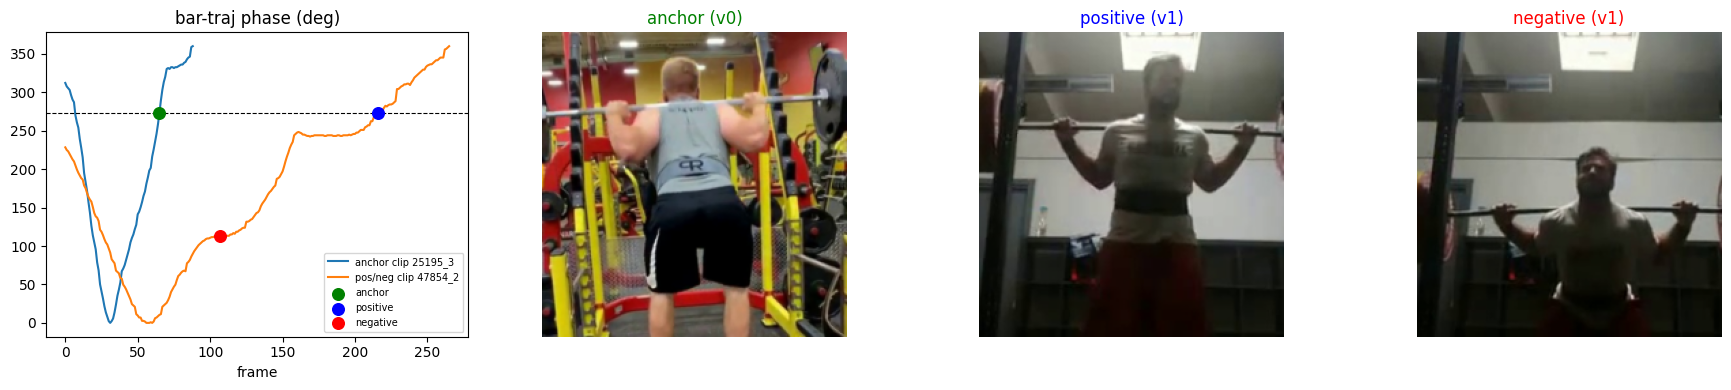


saved .planning/phases/07-image-based-errors-cvcspc/figures/cvcspc_triplet_probe.png


In [3]:
import matplotlib.pyplot as plt
import numpy as np

from backend.training.aqa.datasets.cvcspc_ssl import (
    IMAGENET_MEAN,
    IMAGENET_STD,
    ShallowSquatSSLDataset,
)

ds = ShallowSquatSSLDataset(
    frames_root=FRAMES_ROOT, trajectories_root=TRAJ_ROOT,
    traj_nan_path=TRAJ_NAN_PATH, exclude_ids=EXCLUDE_IDS, ssl_contrastive_phase_gap=30.0,
)
print(f"SSL dataset clips after exclusion: {len(ds)}  (4970 - 179 holdout - degenerate)")

_p0 = ds._load_phase(ds._clip_ids[0])
print(f"sample phase span: {_p0.min():.1f}..{_p0.max():.1f} deg (n={len(_p0)})")

random.seed(0)
sel = ds._select_triplet(0)
v0, v1, p = sel["v0"], sel["v1"], sel["p_anchor"]
ai, pi, ni = sel["anchor_idx"], sel["positive_idx"], sel["negative_idx"]
ph0, ph1 = sel["phase0"], sel["phase1"]
print(f"\nanchor   clip {v0} @ phase {ph0[ai]:.1f}  (target {p:.1f})")
print(f"positive clip {v1} @ phase {ph1[pi]:.1f}")
print(f"negative clip {v1} @ phase {ph1[ni]:.1f}  (|gap|={abs(ph1[ni] - p):.1f} >= 30)")


def _denorm(t):
    m = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
    s = np.array(IMAGENET_STD).reshape(3, 1, 1)
    return np.clip(t.numpy() * s + m, 0, 1).transpose(1, 2, 0)


a_img = _denorm(ds._load_frame(v0, ai))
p_img = _denorm(ds._load_frame(v1, pi))
n_img = _denorm(ds._load_frame(v1, ni))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].plot(ph0, label=f"anchor clip {v0}")
axes[0].plot(ph1, label=f"pos/neg clip {v1}")
axes[0].axhline(p, color="k", ls="--", lw=0.8)
axes[0].scatter([ai], [ph0[ai]], c="g", s=70, zorder=5, label="anchor")
axes[0].scatter([pi], [ph1[pi]], c="b", s=70, zorder=5, label="positive")
axes[0].scatter([ni], [ph1[ni]], c="r", s=70, zorder=5, label="negative")
axes[0].set_title("bar-traj phase (deg)")
axes[0].set_xlabel("frame")
axes[0].legend(fontsize=7)
for ax, im, ttl, c in zip(
    axes[1:], [a_img, p_img, n_img],
    ["anchor (v0)", "positive (v1)", "negative (v1)"], ["g", "b", "r"],
):
    ax.imshow(im)
    ax.set_title(ttl, color=c)
    ax.axis("off")

_figdir = "docs/figures"
os.makedirs(_figdir, exist_ok=True)
plt.tight_layout()
plt.savefig(f"{_figdir}/cvcspc_triplet_probe.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"\nsaved {_figdir}/cvcspc_triplet_probe.png")

In [4]:
from backend.training.aqa.datasets.cvcspc_ssl import build_cvcspc_loader
from backend.training.aqa.harness.cvcspc_pretrain import (
    CVCSPCConfig,
    _triplet_accuracy,
    build_cvcspc_model,
    cvcspc_triplet_loss,
)

_cfg = CVCSPCConfig()
print("CVCSPCConfig:", _cfg)

_loader = build_cvcspc_loader(ds, _cfg, seed=42)
_batch = next(iter(_loader))
for _k in ("anchor", "positive", "negative"):
    print(f"  {_k:9s} {tuple(_batch[_k].shape)} {_batch[_k].dtype}")
    assert _batch[_k].shape == (_cfg.batch_size, 3, 224, 224)

_device = torch.device("cuda")
_backbone, _projector = build_cvcspc_model(_cfg)
_backbone, _projector = _backbone.to(_device), _projector.to(_device)

torch.cuda.reset_peak_memory_stats()
_phi_a = _projector(_backbone(_batch["anchor"].to(_device)))
_phi_p = _projector(_backbone(_batch["positive"].to(_device)))
_phi_n = _projector(_backbone(_batch["negative"].to(_device)))
_loss = cvcspc_triplet_loss(_phi_a, _phi_p, _phi_n)
_loss.backward()
_peak_gb = torch.cuda.max_memory_allocated() / 1e9
print(f"\n3-branch fwd+bwd batch {_cfg.batch_size}: loss={_loss.item():.4f}, "
      f"peak VRAM={_peak_gb:.2f} GB / 23.7 GB")
_unit = torch.allclose(_phi_a.norm(dim=-1), torch.ones(_cfg.batch_size, device=_device), atol=1e-4)
print(f"projector out {tuple(_phi_a.shape)}, unit-norm={_unit}")

_ta = _triplet_accuracy(_backbone, _projector, [_batch], _device)
print(f"triplet-accuracy on the smoke batch: {_ta:.3f} (untrained -> ~0.5)")
assert 0.0 <= _ta <= 1.0

del _backbone, _projector, _loss
torch.cuda.empty_cache()

CVCSPCConfig: CVCSPCConfig(learning_rate=0.0001, weight_decay=0.0, batch_size=25, num_workers=4, max_epochs=100, projector_hidden=128, projector_out_dim=128, phase_gap_start=30.0, phase_gap_decay_every=4, mask_prob=0.5, mask_amt_lo=0.4, mask_amt_hi=0.5, triplet_acc_cadence=5, scheduler_name='cosine', model_arch='resnet18_cvcspc_ssl_v1')
  anchor    (25, 3, 224, 224) torch.float32
  positive  (25, 3, 224, 224) torch.float32
  negative  (25, 3, 224, 224) torch.float32
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 230MB/s]



3-branch fwd+bwd batch 25: loss=1.1790, peak VRAM=1.85 GB / 23.7 GB
projector out (25, 128), unit-norm=True
triplet-accuracy on the smoke batch: 0.480 (untrained -> ~0.5)


In [5]:
import os as _os
import time

from backend.training.aqa.harness.cvcspc_pretrain import run_cvcspc_pretrain_epoch

_t0 = time.perf_counter()
_res = run_cvcspc_pretrain_epoch(
    run_name="shallow_squat_cvcspc_v1_timing",
    drive_root=MYDRIVE,
    frames_root=FRAMES_ROOT, trajectories_root=TRAJ_ROOT,
    traj_nan_path=TRAJ_NAN_PATH, exclude_ids=EXCLUDE_IDS,
    seed=42, resume=False, max_epochs=1,
)
_wall = time.perf_counter() - _t0
_m0 = _res["metrics_history"][0]
_epoch_s = _m0["epoch_wall_time_s"]
print(f"\nepoch-0 time: {_epoch_s:.1f}s ({_epoch_s / 60:.1f} min)  |  cell wall incl setup: {_wall:.1f}s")
print(f"estimated full run (100 ep, UPPER bound): {_epoch_s * 100 / 3600:.2f} h")
print(f"epoch-0 ssl_loss={_m0['ssl_loss_mean']:.4f}")
if _res["triplet_acc_history"]:
    print(f"epoch-0 triplet_acc={_res['triplet_acc_history'][-1]['triplet_acc']:.4f}")

_ck = torch.load(_res["checkpoint_path"], map_location="cpu", weights_only=False)
print(f"\ncheckpoint: {_os.path.basename(_res['checkpoint_path'])}  code_version={_ck['code_version']}")
assert _ck["code_version"] == "phase07-cvcspc-pretrain"


epoch-0 time: 51.8s (0.9 min)  |  cell wall incl setup: 56.0s
estimated full run (100 ep, UPPER bound): 1.44 h
epoch-0 ssl_loss=1.0459
epoch-0 triplet_acc=0.7476

checkpoint: epoch_000.pt  code_version=phase07-cvcspc-pretrain


In [6]:
import logging

from backend.training.aqa.harness.cvcspc_pretrain import (
    CVCSPCConfig,
    run_cvcspc_pretrain_epoch,
)

logging.basicConfig(level=logging.WARNING, format="%(message)s", force=True)
logging.getLogger("aqa.phase07").setLevel(logging.INFO)

RUN_NAME = "shallow_squat_cvcspc_v1"
_config = CVCSPCConfig()
_res = run_cvcspc_pretrain_epoch(
    run_name=RUN_NAME,
    drive_root=MYDRIVE,
    frames_root=FRAMES_ROOT, trajectories_root=TRAJ_ROOT,
    traj_nan_path=TRAJ_NAN_PATH, exclude_ids=EXCLUDE_IDS,
    seed=42, config=_config, resume=True, max_epochs=_config.max_epochs,
)
_best_ta = max((e["triplet_acc"] for e in _res["triplet_acc_history"]), default=float("nan"))
print(f"\nSSL done: final epoch {_res['epoch']}, best triplet_acc {_best_ta:.4f}")
print(f"backbone.pt: {_res['backbone_path']}")
print(f"final phase_gap: {_config.phase_gap_start}")

run_dir: /content/drive/MyDrive/FitNova/checkpoints/phase07/shallow_squat_cvcspc_v1 (config_hash=2b46d6a2b73aae00)
no traj_nan_path provided; relying on the degenerate-trajectory guard
ShallowSquatSSLDataset: 4791 clips (excluded 0 traj_nan, 179 holdout, 0 degenerate)
build_cvcspc_model: ResNet-18 (ImageNet, fc=Identity) + projection head — 11258688 params


epoch=0 triplet_acc=0.7476
epoch=0 ssl_loss=1.045871 phase_gap=30.0 wall=45.6s
New best triplet_acc=0.7476 -> wrote backbone.pt


epoch=1 ssl_loss=0.819515 phase_gap=30.0 wall=27.0s


epoch=2 ssl_loss=0.704420 phase_gap=30.0 wall=27.2s


epoch=3 ssl_loss=0.682023 phase_gap=30.0 wall=26.9s


...

epoch=96 ssl_loss=0.268325 phase_gap=30.0 wall=24.6s


epoch=97 ssl_loss=0.262742 phase_gap=30.0 wall=24.3s


epoch=98 ssl_loss=0.255235 phase_gap=30.0 wall=24.3s


epoch=99 ssl_loss=0.265610 phase_gap=30.0 wall=24.3s



SSL done: final epoch 99, best triplet_acc 0.9590
backbone.pt: /content/drive/MyDrive/FitNova/checkpoints/phase07/shallow_squat_cvcspc_v1/backbone.pt
final phase_gap: 30.0


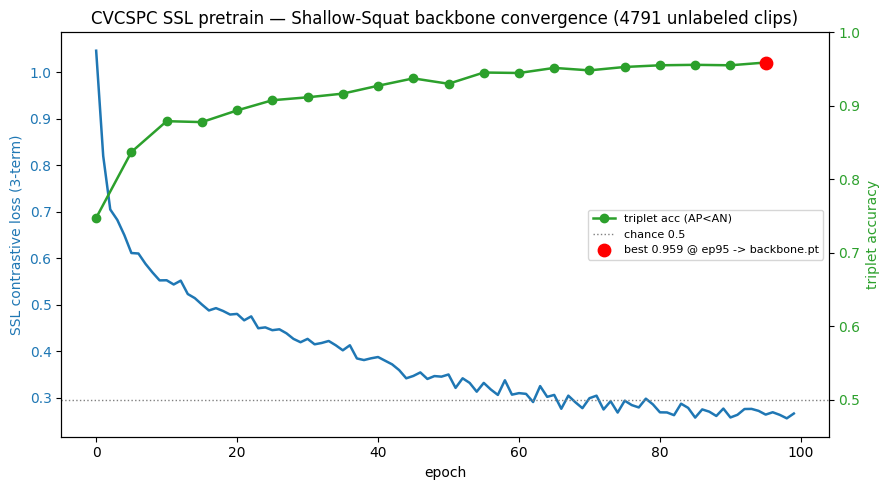

saved .planning/phases/07-image-based-errors-cvcspc/figures/cvcspc_ssl_curves.png  (loss 1.046->0.266, triplet_acc 0.748->0.959)


In [7]:
import matplotlib.pyplot as plt

_run_dir = f"{MYDRIVE}/FitNova/checkpoints/phase07/shallow_squat_cvcspc_v1"
with open(f"{_run_dir}/latest.txt") as _f:
    _latest = _f.read().strip()
_ck = torch.load(f"{_run_dir}/{_latest}", map_location="cpu", weights_only=False)
_mh, _tah = _ck["metrics_history"], _ck["triplet_acc_history"]

_ep = [m["epoch"] for m in _mh]
_loss = [m["ssl_loss_mean"] for m in _mh]
_ta_ep = [t["epoch"] for t in _tah]
_ta = [t["triplet_acc"] for t in _tah]
_best = max(_ta)
_best_ep = _ta_ep[_ta.index(_best)]

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(_ep, _loss, color="tab:blue", lw=1.8)
ax1.set_xlabel("epoch")
ax1.set_ylabel("SSL contrastive loss (3-term)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(_ta_ep, _ta, color="tab:green", marker="o", lw=1.8, label="triplet acc (AP<AN)")
ax2.axhline(0.5, color="gray", ls=":", lw=1, label="chance 0.5")
ax2.scatter([_best_ep], [_best], color="red", s=80, zorder=5,
            label=f"best {_best:.3f} @ ep{_best_ep} -> backbone.pt")
ax2.set_ylabel("triplet accuracy", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")
ax2.set_ylim(0.45, 1.0)
ax2.legend(loc="center right", fontsize=8)
ax1.set_title("CVCSPC SSL pretrain — Shallow-Squat backbone convergence (4791 unlabeled clips)")

_figdir = "docs/figures"
os.makedirs(_figdir, exist_ok=True)
plt.tight_layout()
plt.savefig(f"{_figdir}/cvcspc_ssl_curves.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"saved {_figdir}/cvcspc_ssl_curves.png  "
      f"(loss {_loss[0]:.3f}->{_loss[-1]:.3f}, triplet_acc {_ta[0]:.3f}->{_best:.3f})")

In [8]:
from backend.training.aqa.harness import _envinit

import torch
import torch.nn as nn

from backend.training.aqa.harness.colab import mount_drive, stage_shallow_squat_images

MYDRIVE = mount_drive()
SHALLOW_ROOT = stage_shallow_squat_images(MYDRIVE, local_root="/content/squat_shallow_images")
IMAGES_ROOT = os.path.join(SHALLOW_ROOT, "crops_unaligned")
LABELS_PATH = os.path.join(SHALLOW_ROOT, "labels_shallow_depth.json")
SPLITS_ROOT = os.path.join(SHALLOW_ROOT, "splits")
print("labeled crops:", IMAGES_ROOT)

BACKBONE_PATH = os.path.join(
    MYDRIVE, "FitNova/checkpoints/phase07/shallow_squat_cvcspc_v1/backbone.pt"
)
assert os.path.exists(BACKBONE_PATH), f"backbone.pt missing: {BACKBONE_PATH}"
assert "shallow_squat_cvcspc_v1" in BACKBONE_PATH, "must be the CVCSPC backbone, not from-scratch"


def build_cvcspc_finetune_model(backbone_path=BACKBONE_PATH):
    from torchvision.models import resnet18

    model = resnet18(weights=None)
    ckpt = torch.load(backbone_path, map_location="cpu", weights_only=False)
    model.load_state_dict(ckpt["backbone_state_dict"], strict=False)
    model.fc = nn.Linear(512, 1)
    return model


_ck = torch.load(BACKBONE_PATH, map_location="cpu", weights_only=False)
from torchvision.models import resnet18 as _r18

_miss, _unexp = _r18(weights=None).load_state_dict(_ck["backbone_state_dict"], strict=False)
print(f"backbone code_version={_ck.get('code_version')} | strict=False load: "
      f"{len(_miss)} missing (expect fc.*), {len(_unexp)} unexpected")

_m = build_cvcspc_finetune_model().cuda()
with torch.no_grad():
    _out = _m(torch.zeros(2, 3, 224, 224, device="cuda"))
assert isinstance(_m.fc, nn.Linear) and _m.fc.out_features == 1
assert tuple(_out.shape) == (2, 1)
print(f"head {_m.fc} | forward zeros[2,3,224,224] -> {tuple(_out.shape)}")
del _m
torch.cuda.empty_cache()

labeled crops: /content/squat_shallow_images/crops_unaligned
backbone code_version=phase07-cvcspc-pretrain | strict=False load: 2 missing (expect fc.*), 0 unexpected
head Linear(in_features=512, out_features=1, bias=True) | forward zeros[2,3,224,224] -> (2, 1)


In [9]:
import logging

from backend.training.aqa.datasets.shallow_squat import ShallowSquatDataset
from backend.training.aqa.harness.image_supervised_train import ImageConfig, run_image_epoch

logging.basicConfig(level=logging.WARNING, format="%(message)s", force=True)
logging.getLogger("aqa.phase07").setLevel(logging.INFO)

SEEDS = [42, 1337, 7]
_ft_results = {}

_n = 42
_ft_results[_n] = run_image_epoch(
    run_name=f"shallow_squat_cvcspc_finetune_seed{_n}",
    drive_root=MYDRIVE,
    images_root=IMAGES_ROOT, labels_path=LABELS_PATH, splits_root=SPLITS_ROOT,
    seed=_n, config=ImageConfig(), resume=True, max_epochs=50,
    dataset_cls=ShallowSquatDataset,
    model_builder=lambda: build_cvcspc_finetune_model(),
)
_r = _ft_results[_n]
print(f"\nseed {_n}: best_f1_val={_r['best_f1_val']:.4f}  (last epoch {_r['epoch']})")
print(f"best.pt: {_r['best_checkpoint_path']}")

run_dir: /content/drive/MyDrive/FitNova/checkpoints/phase07/shallow_squat_cvcspc_finetune_seed42 (config_hash=402ca64442078859)
pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[train]: 2542 records
pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[val]: 529 records
pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[test]: 540 records


epoch=0 val_loss=0.324981 val_f1=0.8601 val_pr_auc=0.9490 wall=6.0s
New best val_f1=0.8601 -> wrote best.pt


epoch=1 val_loss=0.315895 val_f1=0.8711 val_pr_auc=0.9481 wall=5.4s
New best val_f1=0.8711 -> wrote best.pt


epoch=2 val_loss=0.313301 val_f1=0.8780 val_pr_auc=0.9543 wall=5.6s
New best val_f1=0.8780 -> wrote best.pt


epoch=3 val_loss=0.319760 val_f1=0.8848 val_pr_auc=0.9532 wall=5.5s
New best val_f1=0.8848 -> wrote best.pt


...

epoch=17 val_loss=0.407902 val_f1=0.8940 val_pr_auc=0.9658 wall=5.5s


epoch=18 val_loss=0.405687 val_f1=0.8740 val_pr_auc=0.9595 wall=5.4s


epoch=19 val_loss=0.363415 val_f1=0.8821 val_pr_auc=0.9620 wall=5.4s


epoch=20 val_loss=0.406423 val_f1=0.8838 val_pr_auc=0.9598 wall=5.5s
Early stopping at epoch 20 (best=0.8961 after 8 without improvement)



seed 42: best_f1_val=0.8961  (last epoch 20)
best.pt: /content/drive/MyDrive/FitNova/checkpoints/phase07/shallow_squat_cvcspc_finetune_seed42/best.pt


In [10]:
for _n in SEEDS[1:]:
    print(f"\n===== seed {_n} =====")
    _ft_results[_n] = run_image_epoch(
        run_name=f"shallow_squat_cvcspc_finetune_seed{_n}",
        drive_root=MYDRIVE,
        images_root=IMAGES_ROOT, labels_path=LABELS_PATH, splits_root=SPLITS_ROOT,
        seed=_n, config=ImageConfig(), resume=True, max_epochs=50,
        dataset_cls=ShallowSquatDataset,
        model_builder=lambda: build_cvcspc_finetune_model(),
    )

print("\n\nper-seed best val F1 — CVCSPC fine-tune vs supervised baseline:")
for _n in SEEDS:
    _bl = torch.load(
        f"{MYDRIVE}/FitNova/checkpoints/phase07/shallow_squat_baseline_seed{_n}/best.pt",
        map_location="cpu", weights_only=False,
    )["best_f1_val"]
    _cv = _ft_results[_n]["best_f1_val"]
    print(f"  seed {_n:5d}: CVCSPC {_cv:.4f}  vs  baseline {_bl:.4f}  (delta {_cv - _bl:+.4f})")

run_dir: /content/drive/MyDrive/FitNova/checkpoints/phase07/shallow_squat_cvcspc_finetune_seed1337 (config_hash=0e3a534a23f212ac)
pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[train]: 2542 records
pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[val]: 529 records
pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[test]: 540 records



===== seed 1337 =====


epoch=0 val_loss=0.361282 val_f1=0.8428 val_pr_auc=0.9409 wall=5.8s
New best val_f1=0.8428 -> wrote best.pt


epoch=1 val_loss=0.332401 val_f1=0.8531 val_pr_auc=0.9441 wall=5.5s
New best val_f1=0.8531 -> wrote best.pt


epoch=2 val_loss=0.346354 val_f1=0.8679 val_pr_auc=0.9387 wall=5.5s
New best val_f1=0.8679 -> wrote best.pt


...

epoch=10 val_loss=0.392246 val_f1=0.8637 val_pr_auc=0.9609 wall=5.6s


epoch=11 val_loss=0.370220 val_f1=0.8682 val_pr_auc=0.9564 wall=5.5s


epoch=12 val_loss=0.434670 val_f1=0.8559 val_pr_auc=0.9544 wall=5.6s


epoch=13 val_loss=0.377474 val_f1=0.8711 val_pr_auc=0.9528 wall=5.4s
Early stopping at epoch 13 (best=0.8934 after 8 without improvement)




per-seed best val F1 — CVCSPC fine-tune vs Plan-02 baseline:
  seed    42: CVCSPC 0.8961  vs  baseline 0.8760  (delta +0.0201)
  seed  1337: CVCSPC 0.8911  vs  baseline 0.8715  (delta +0.0196)
  seed     7: CVCSPC 0.8934  vs  baseline 0.8845  (delta +0.0089)


In [11]:
import pickle
from pathlib import Path

import numpy as np
from torch.utils.data import DataLoader

from backend.training.aqa.datasets.shallow_squat import ShallowSquatDataset
from backend.training.aqa.eval.metrics import (
    confusion_matrix_per_error,
    f1_per_error,
    pr_auc_per_error,
    threshold_sweep,
)
from backend.training.aqa.harness.image_supervised_train import build_resnet18

_device = torch.device("cuda")
_ckdir = f"{MYDRIVE}/FitNova/checkpoints/phase07"


def _split_loader(split):
    ds = ShallowSquatDataset(split=split, images_root=IMAGES_ROOT, labels_path=LABELS_PATH,
                             splits_root=SPLITS_ROOT, train_aug=False)
    return DataLoader(ds, batch_size=64, shuffle=False, num_workers=0)


@torch.no_grad()
def _gather(model, loader):
    model.eval()
    scs, lbs = [], []
    for _img, _lbl in loader:
        scs.append(torch.sigmoid(model(_img.to(_device))).squeeze(-1).cpu())
        lbs.append(_lbl)
    return torch.cat(scs).numpy(), torch.cat(lbs).numpy().astype(int)


_val_loader, _test_loader = _split_loader("val"), _split_loader("test")


def _gather_family(prefix):
    pv, pt, vl, tl = {}, {}, None, None
    for _n in SEEDS:
        _ck = torch.load(f"{_ckdir}/{prefix}_seed{_n}/best.pt", map_location=_device, weights_only=False)
        _m = build_resnet18()
        _m.load_state_dict(_ck["model_state_dict"])
        _m = _m.to(_device)
        pv[_n], vl = _gather(_m, _val_loader)
        pt[_n], tl = _gather(_m, _test_loader)
        del _m
        torch.cuda.empty_cache()
    return pv, pt, vl, tl


_cv_pv, _cv_pt, _val_labels, _test_labels = _gather_family("shallow_squat_cvcspc_finetune")
_bl_pv, _bl_pt, _, _ = _gather_family("shallow_squat_baseline")


def _ensemble_eval(pv, pt):
    ev = np.mean([pv[n] for n in SEEDS], axis=0)
    et = np.mean([pt[n] for n in SEEDS], axis=0)
    t, _ = threshold_sweep(_val_labels, ev)
    vf1 = f1_per_error(_val_labels, (ev >= t).astype(int))
    tf1 = f1_per_error(_test_labels, (et >= t).astype(int))
    return ev, et, t, vf1, tf1


_cv_ev, _cv_et, _cv_t, _cv_vf1, _cv_tf1 = _ensemble_eval(_cv_pv, _cv_pt)
_bl_ev, _bl_et, _bl_t, _bl_vf1, _bl_tf1 = _ensemble_eval(_bl_pv, _bl_pt)

_cv_pr = pr_auc_per_error(_test_labels, _cv_et)
_cv_cm = confusion_matrix_per_error(_test_labels, (_cv_et >= _cv_t).astype(int))
_cv_per_seed_test = {n: f1_per_error(_test_labels, (_cv_pt[n] >= _cv_t).astype(int)) for n in SEEDS}
_best_seed = max(SEEDS, key=lambda n: f1_per_error(_val_labels, (_cv_pv[n] >= 0.5).astype(int)))
_cv_single = f1_per_error(_test_labels, (_cv_pt[_best_seed] >= _cv_t).astype(int))

_ssl_lift = _cv_tf1 - _bl_tf1
_val_test_gap = abs(_cv_vf1 - _cv_tf1)
PAPER = {"cvcspc": 0.8694, "simsiam": 0.8286, "openpose_tdm": 0.8340}

print("=" * 62)
print("SHALLOW-SQUAT — baseline -> CVCSPC -> paper (official 540-crop test F1)")
print("=" * 62)
print(f"  our supervised baseline (control) : {_bl_tf1:.4f}  @ t*={_bl_t:.3f}")
print(f"  our CVCSPC ensemble               : {_cv_tf1:.4f}  @ t*={_cv_t:.3f}  (PR-AUC {_cv_pr:.4f})")
print(f"  SSL lift (CVCSPC - baseline)      : {_ssl_lift:+.4f}")
print(f"  CVCSPC single best-seed ({_best_seed})        : {_cv_single:.4f}")
print(f"  per-seed CVCSPC test F1           : " + ", ".join(f"{n}:{_cv_per_seed_test[n]:.4f}" for n in SEEDS))
print(f"  val->test gap (CVCSPC)            : {_val_test_gap:.4f}"
      + ("   [>0.05 — check over-tuning]" if _val_test_gap > 0.05 else ""))
print("-" * 62)
print(f"  paper CVCSPC (SSL target)         : {PAPER['cvcspc']:.4f}")
print(f"  paper SimSiam (image SSL)         : {PAPER['simsiam']:.4f}")
print(f"  paper OpenPose-TDM (2D pose)      : {PAPER['openpose_tdm']:.4f}")
print(f"  confusion [[TN,FP],[FN,TP]]:\n{_cv_cm}")


def _curve(prefix, n):
    rd = f"{_ckdir}/{prefix}_seed{n}"
    with open(f"{rd}/latest.txt") as _f:
        return torch.load(f"{rd}/{_f.read().strip()}", map_location="cpu", weights_only=False)["metrics_history"]


_ssl_rd = f"{_ckdir}/shallow_squat_cvcspc_v1"
with open(f"{_ssl_rd}/latest.txt") as _f:
    _ssl_tah = torch.load(f"{_ssl_rd}/{_f.read().strip()}", map_location="cpu", weights_only=False)["triplet_acc_history"]

_results = {
    "ssl_triplet_acc": _ssl_tah,
    "finetune_seeds": {n: _curve("shallow_squat_cvcspc_finetune", n) for n in SEEDS},
    "baseline_seeds": {n: _curve("shallow_squat_baseline", n) for n in SEEDS},
    "ensemble_val_scores": _cv_ev, "ensemble_test_scores": _cv_et,
    "val_labels": _val_labels, "test_labels": _test_labels,
    "best_threshold": _cv_t,
    "test_f1": {"cvcspc_ensemble": _cv_tf1, "single_model": _cv_single, "per_seed": _cv_per_seed_test},
    "test_pr_auc": _cv_pr, "test_confusion": _cv_cm,
    "baseline_control": {"test_f1": _bl_tf1, "threshold": _bl_t, "ensemble_test_scores": _bl_et,
                         "ensemble_val_f1": _bl_vf1},
    "cvcspc_ensemble_val_f1": _cv_vf1,
    "ssl_lift": _ssl_lift, "val_test_gap": _val_test_gap,
    "paper_targets": PAPER,
    "loss_deviation_note": "SSL pretrained with the 3-term code loss (train_test.py:68); paper Eq.1 is 2-term.",
    "seeds": SEEDS,
}
_drive_pkl = f"{_ckdir}/results.pkl"
with open(_drive_pkl, "wb") as _f:
    pickle.dump(_results, _f)
_repo_pkl = Path("backend/data/benchmark/shallow/results.pkl")
_repo_pkl.parent.mkdir(parents=True, exist_ok=True)
with open(_repo_pkl, "wb") as _f:
    pickle.dump(_results, _f)
print(f"\nwrote results.pkl -> Drive ({_drive_pkl}) + repo ({_repo_pkl}), "
      f"{len(pickle.dumps(_results)) / 1e3:.0f} KB")

pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[val]: 529 records
pos_weight from train (N=2542): pos=1099 -> w=1.3130
ShallowSquatDataset[test]: 540 records
Model: ResNet-18 + Linear(512, 1) head, 11177025 params
Model: ResNet-18 + Linear(512, 1) head, 11177025 params
Model: ResNet-18 + Linear(512, 1) head, 11177025 params
Model: ResNet-18 + Linear(512, 1) head, 11177025 params
Model: ResNet-18 + Linear(512, 1) head, 11177025 params
Model: ResNet-18 + Linear(512, 1) head, 11177025 params


SHALLOW-SQUAT — baseline -> CVCSPC -> paper (official 540-crop test F1)
  our supervised baseline (control) : 0.8750  @ t*=0.473
  our CVCSPC ensemble               : 0.8902  @ t*=0.395  (PR-AUC 0.9668)
  SSL lift (CVCSPC - baseline)      : +0.0152
  CVCSPC single best-seed (42)        : 0.8961
  per-seed CVCSPC test F1           : 42:0.8961, 1337:0.8902, 7:0.8825
  val->test gap (CVCSPC)            : 0.0217
--------------------------------------------------------------
  paper CVCSPC (SSL target)         : 0.8694
  paper SimSiam (image SSL)         : 0.8286
  paper OpenPose-TDM (2D pose)      : 0.8340
  confusion [[TN,FP],[FN,TP]]:
[[262  42]
 [ 13 223]]

wrote results.pkl -> Drive (/content/drive/MyDrive/FitNova/checkpoints/phase07/results.pkl) + repo (.planning/phases/07-image-based-errors-cvcspc/figures/results.pkl), 113 KB


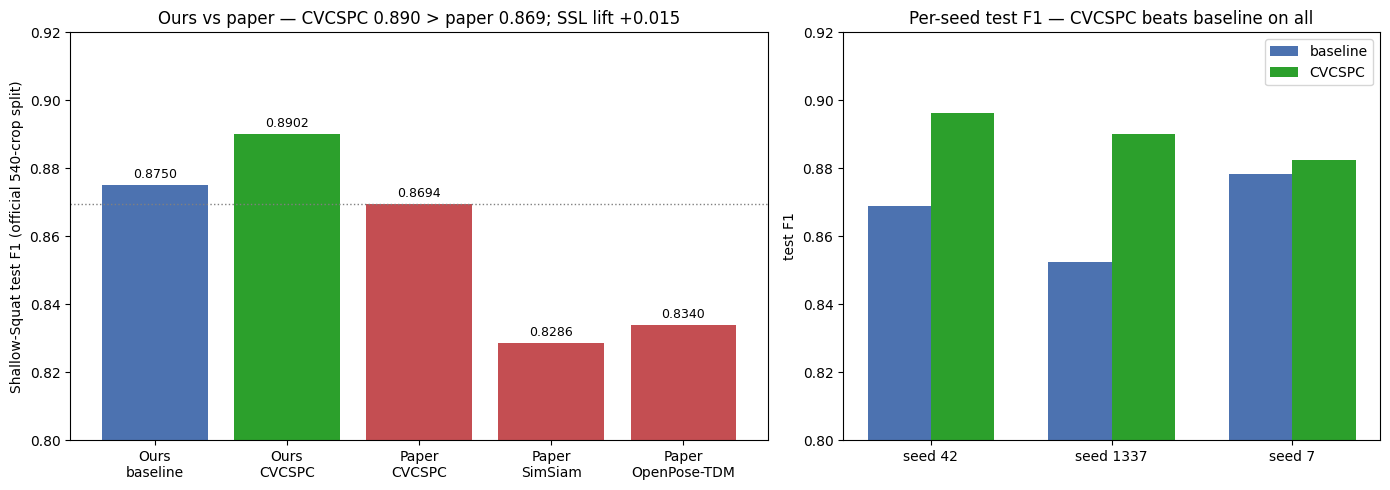

saved figures/cvcspc_comparison.png


In [14]:
import matplotlib.pyplot as plt

_methods = ["Ours\nbaseline", "Ours\nCVCSPC", "Paper\nCVCSPC", "Paper\nSimSiam", "Paper\nOpenPose-TDM"]
_vals = [_bl_tf1, _cv_tf1, PAPER["cvcspc"], PAPER["simsiam"], PAPER["openpose_tdm"]]
_colors = ["#4C72B0", "#2CA02C", "#C44E52", "#C44E52", "#C44E52"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.3, 1]})
for _b, _v in zip(ax1.bar(_methods, _vals, color=_colors), _vals):
    ax1.text(_b.get_x() + _b.get_width() / 2, _v + 0.002, f"{_v:.4f}", ha="center", fontsize=9)
ax1.axhline(PAPER["cvcspc"], color="gray", ls=":", lw=1)
ax1.set_ylim(0.80, 0.92)
ax1.set_ylabel("Shallow-Squat test F1 (official 540-crop split)")
ax1.set_title(f"Ours vs paper — CVCSPC {_cv_tf1:.3f} > paper {PAPER['cvcspc']:.3f}; SSL lift +{_ssl_lift:.3f}")

_x = np.arange(len(SEEDS))
_w = 0.35
_bl_seed = {n: f1_per_error(_test_labels, (_bl_pt[n] >= _bl_t).astype(int)) for n in SEEDS}
ax2.bar(_x - _w / 2, [_bl_seed[n] for n in SEEDS], _w, label="baseline", color="#4C72B0")
ax2.bar(_x + _w / 2, [_cv_per_seed_test[n] for n in SEEDS], _w, label="CVCSPC", color="#2CA02C")
ax2.set_xticks(_x)
ax2.set_xticklabels([f"seed {n}" for n in SEEDS])
ax2.set_ylim(0.80, 0.92)
ax2.set_ylabel("test F1")
ax2.set_title("Per-seed test F1 — CVCSPC beats baseline on all")
ax2.legend()

os.makedirs("docs/figures", exist_ok=True)
plt.tight_layout()
plt.savefig("docs/figures/cvcspc_comparison.png",
            dpi=130, bbox_inches="tight")
plt.show()
print("saved figures/cvcspc_comparison.png")